## Topic 1: Introduction to RMSProp & The Problem It Solves

### 1. Introduction

**What is RMSProp?**
RMSProp stands for **Root Mean Square Propagation**. It is an optimization algorithm used in deep learning to help neural networks learn more effectively.

**Why is it important?**
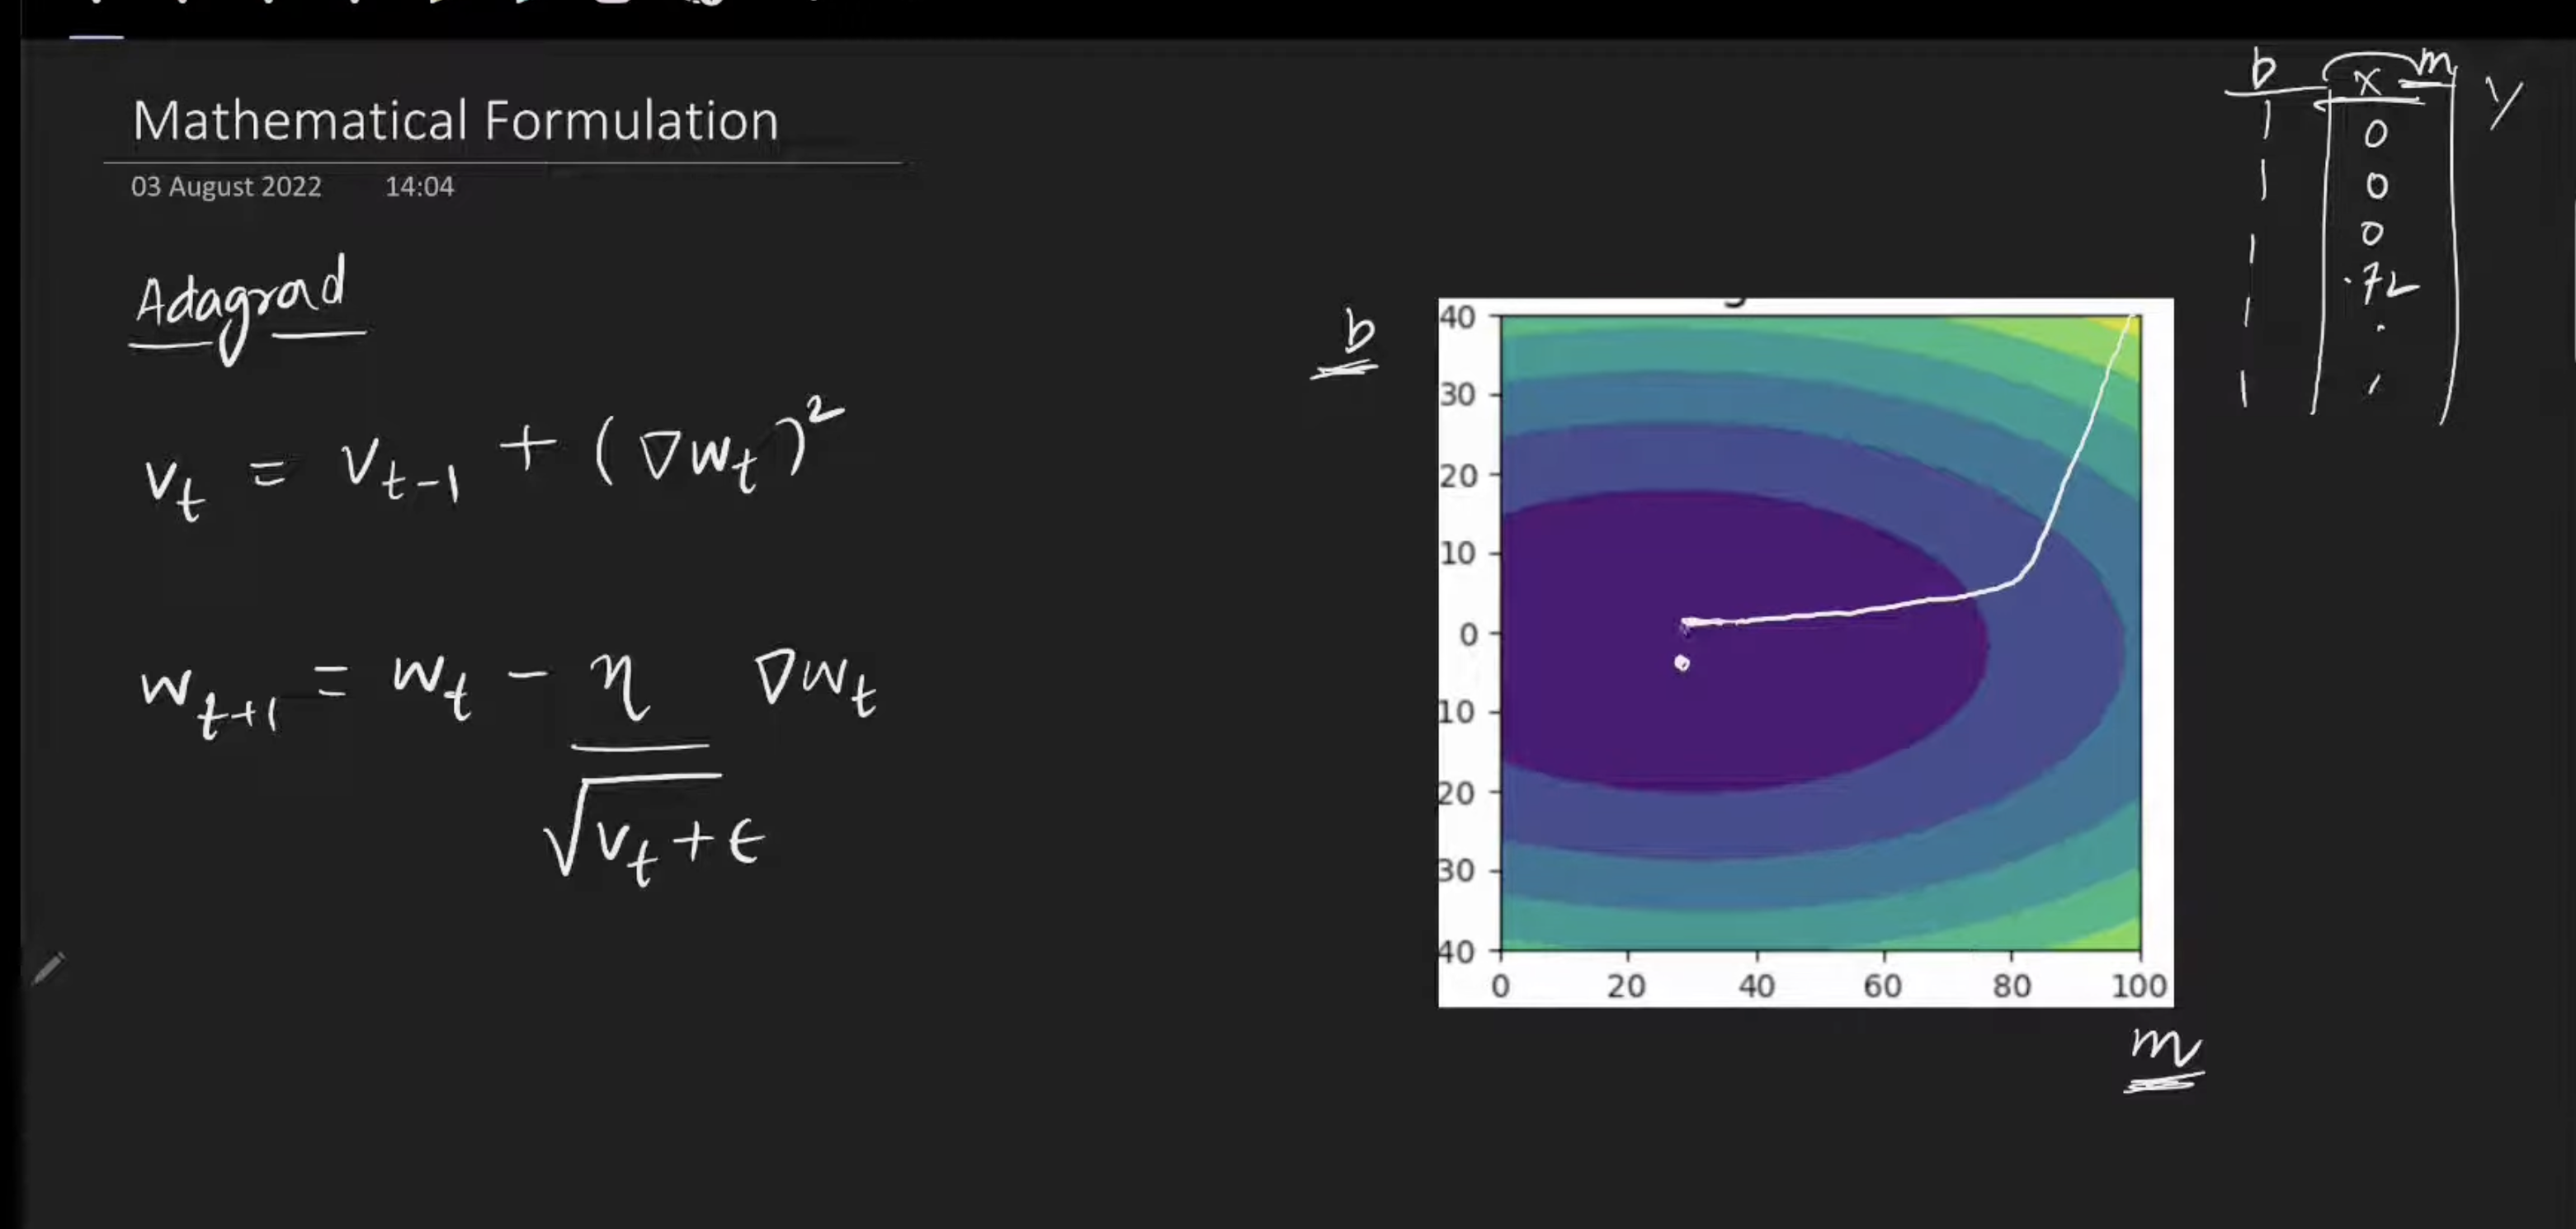
When training neural networks, we need to find the "minimum" (best solution) of a function. RMSProp improves upon an earlier optimizer called **AdaGrad** by fixing a major weakness: AdaGrad slows down too much and gets stuck before reaching the optimal solution.

**Real-life use:**
- Training complex neural networks (non-convex optimization problems)
- Deep learning models where standard optimizers fail
- Still used today as a backup when the more popular "Adam" optimizer doesn't give good results

---

### 2. Detailed Explanation

**The Problem with AdaGrad (Background)**

Imagine you are trying to reach the lowest point in a valley. Some directions are steep, others are shallow.

- **AdaGrad** keeps track of all the past "steps" (gradients) you have taken.
- It adds up the **squares** of all past gradients.
- As you take more steps, this sum becomes very large.
- When the sum becomes large, the learning rate (step size) becomes **very small**.
- Eventually, the updates become so tiny that the algorithm **stops moving** before reaching the true minimum.

**Mathematical Problem of AdaGrad:**

```
Learning rate for a parameter = (Original learning rate) ÷ (√(sum of all past squared gradients))
```

- "Sum of all past squared gradients" keeps growing forever
- The denominator gets bigger → learning rate gets smaller → updates become negligible → algorithm gets stuck

**The RMSProp Solution:**

Instead of adding up **all** past squared gradients (which grows forever), RMSProp uses **Exponentially Weighted Average** (also called moving average).

**Key insight:** Give more importance to **recent** gradients and gradually "forget" older ones.

- Recent gradients get high value/weight
- Old gradients get very low value/weight (they fade away)
- This prevents the sum from becoming too large
- The learning rate never becomes too small
- Updates continue happening, so the algorithm can reach the minimum

**Analogy:**
- **AdaGrad** = Remembering every single meal you've ever eaten. Your "memory" keeps growing forever.
- **RMSProp** = Remembering recent meals more clearly, while older meals fade from memory. Your "memory" stays manageable.

---

### 3. Key Points

| Feature | AdaGrad | RMSProp |
|---------|---------|---------|
| Gradient history | Uses ALL past squared gradients | Uses weighted average (recent = more important) |
| Learning rate | Becomes very small over time | Stays reasonable |
| Convergence | Gets stuck before minimum | Reaches minimum |
| Best for | Convex problems (simple, bowl-shaped) | Non-convex problems (complex neural networks) |

**Summary:**
- ✓ RMSProp solves AdaGrad's "dying learning rate" problem
- ✓ Works well for both linear regression AND complex neural networks
- ✓ Uses recent gradient information more than old information
- ✓ One of the best optimization techniques for neural networks

---

### 7. Common Mistakes

| Mistake | Why it happens | How to avoid |
|---------|---------------|--------------|
| Thinking RMSProp uses ALL past gradients | Confusing with AdaGrad | Remember: RMSProp uses **exponentially weighted average**, not full sum |
| Expecting RMSProp to always beat Adam | Adam is newer and often better | Use RMSProp when Adam doesn't give good results for your specific problem |

---

### 8. Interview/Exam Questions

**Q1: What is the main problem with AdaGrad that RMSProp solves?**
> **A:** AdaGrad accumulates the sum of all past squared gradients, causing the denominator to grow too large. This makes the learning rate extremely small, so updates become negligible and the algorithm gets stuck before reaching the minimum. RMSProp uses exponentially weighted average instead, preventing the denominator from growing too large.

**Q2: What does RMSProp stand for?**
> **A:** Root Mean Square Propagation

**Q3: For which type of optimization problems does RMSProp work better than AdaGrad?**
> **A:** Non-convex optimization problems (complex neural networks). AdaGrad works fine for convex problems (like linear regression), but RMSProp works well for both.

---

### 9. Revision Notes

- **RMSProp** = Root Mean Square Propagation
- **Problem it solves**: AdaGrad's learning rate becomes too small → algorithm gets stuck
- **Solution**: Use **exponentially weighted average** instead of full sum of squared gradients
- **Effect**: Recent gradients get more importance; old gradients are forgotten
- **Result**: Learning rate never becomes too small → algorithm reaches minimum
- **Best for**: Complex neural networks (non-convex problems)
- **Current status**: Still used today when Adam doesn't work well

---



## Topic 2: Mathematical Formula & Exponentially Weighted Average

### 1. Introduction

**What is Exponentially Weighted Average?**
It's a mathematical technique that calculates a moving average where **recent values have more influence** than older values. RMSProp uses this to track gradient history without letting the numbers grow too large.

**Why is this important for RMSProp?**
This is the **core mathematical innovation** of RMSProp. Without understanding this, you won't understand why RMSProp works better than AdaGrad.

**Real-life analogy:**
- **Regular average** = Giving equal weight to your test scores from 1st grade and 12th grade
- **Exponentially weighted average** = Caring more about recent tests, barely remembering what you scored years ago

---

### 2. Detailed Explanation

**The RMSProp Formulas**
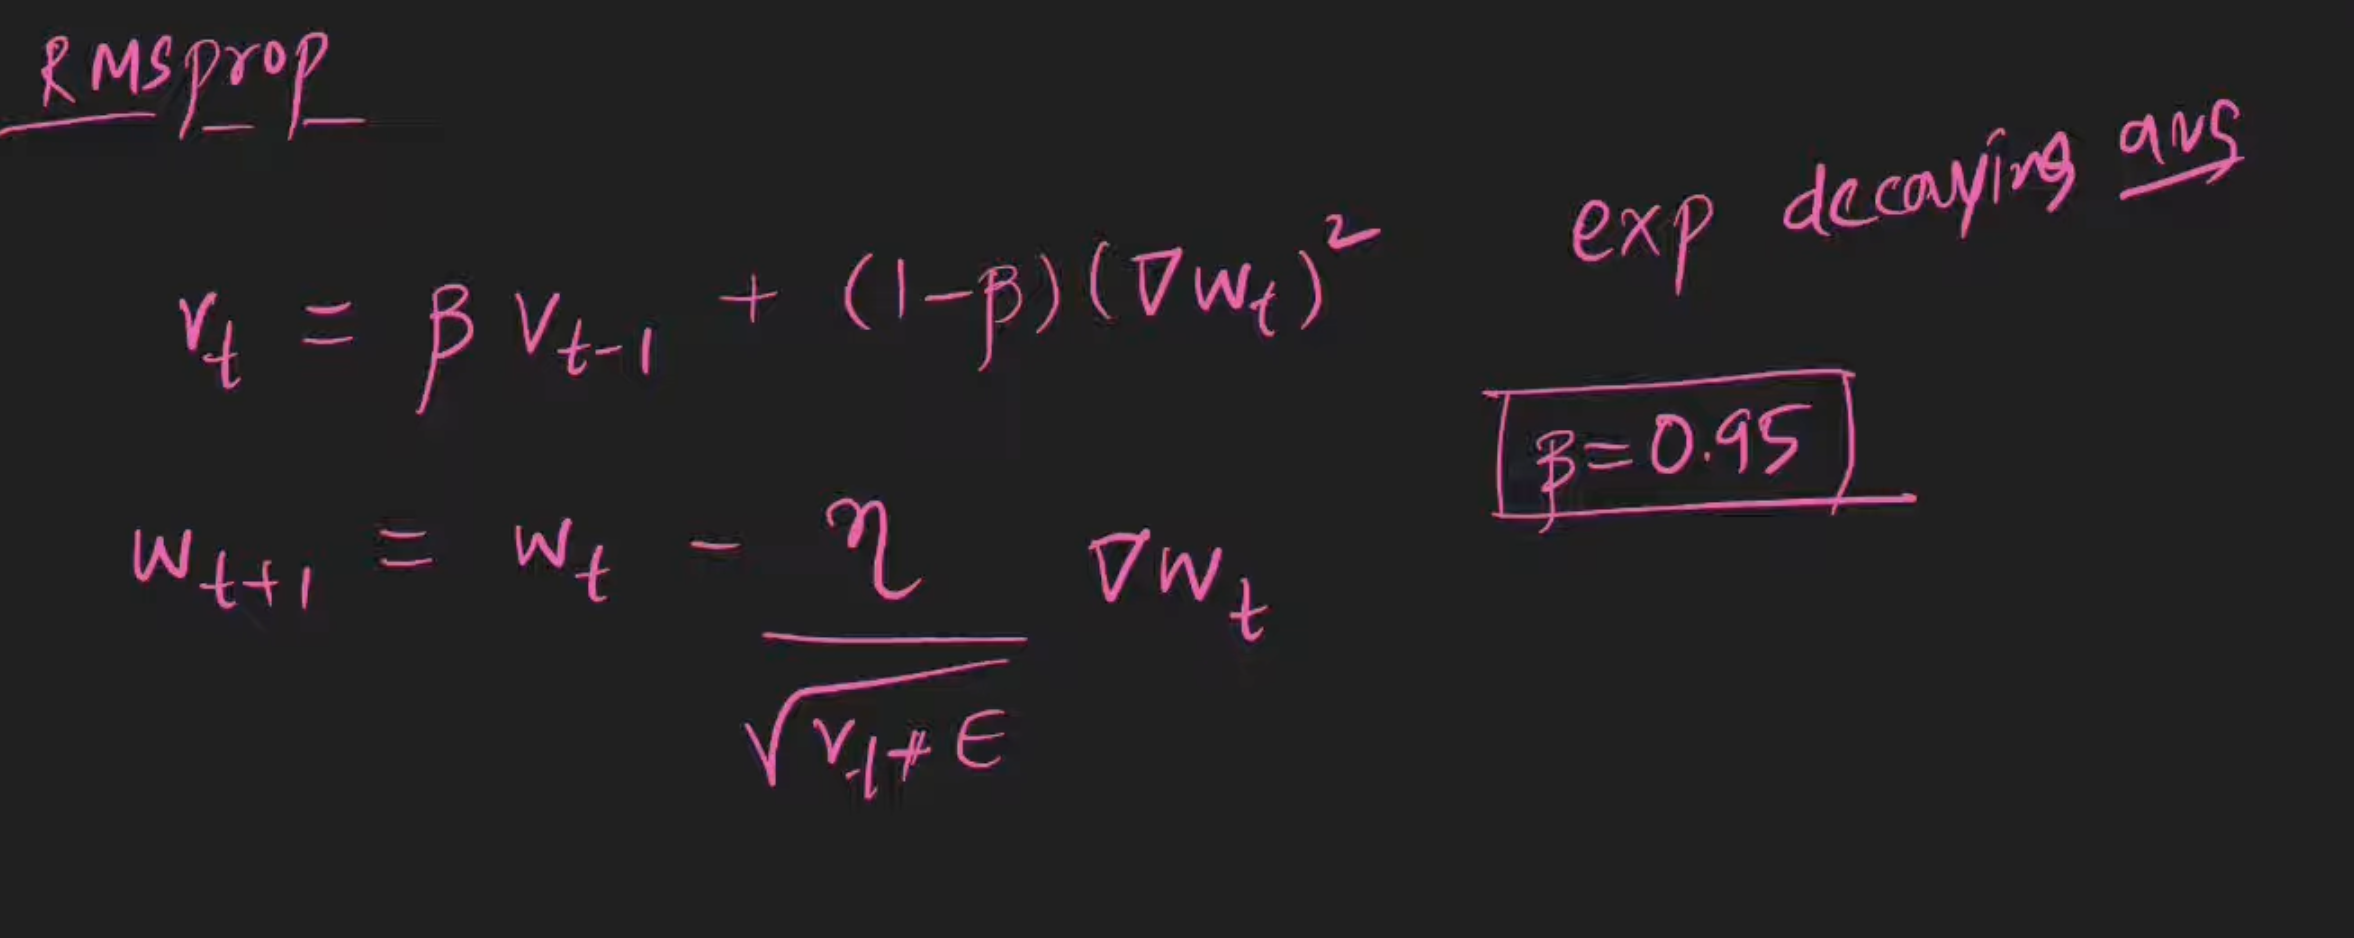
RMSProp uses **two main formulas**:

**Formula 1: Updating the squared gradient average (Vₜ)**
```
Vₜ = β × Vₜ₋₁ + (1 - β) × (gradient)²
```

**Formula 2: Updating the parameter (W)**
```
Wₜ = Wₜ₋₁ - (learning rate ÷ √(Vₜ + ε)) × gradient
```

**Breaking down Formula 1 (Vₜ):**

| Symbol | Meaning | Typical Value |
|--------|---------|---------------|
| Vₜ | Current weighted average of squared gradients | Calculated each step |
| Vₜ₋₁ | Previous step's weighted average | From last iteration |
| β (beta) | Decay rate - how much to "forget" old values | 0.9 or 0.95 |
| gradient | Current gradient (slope) at this step | Varies |
| (gradient)² | Square of the gradient | Always positive |

**What β (beta) does:**
- β = 0.9 means: 90% from previous average, 10% from current gradient
- Higher β = more weight on past history (smoother, but slower to adapt)
- Lower β = more weight on recent changes (more responsive, but noisier)

**How the "forgetting" works mathematically:**

Let's trace through an example with **β = 0.95**:
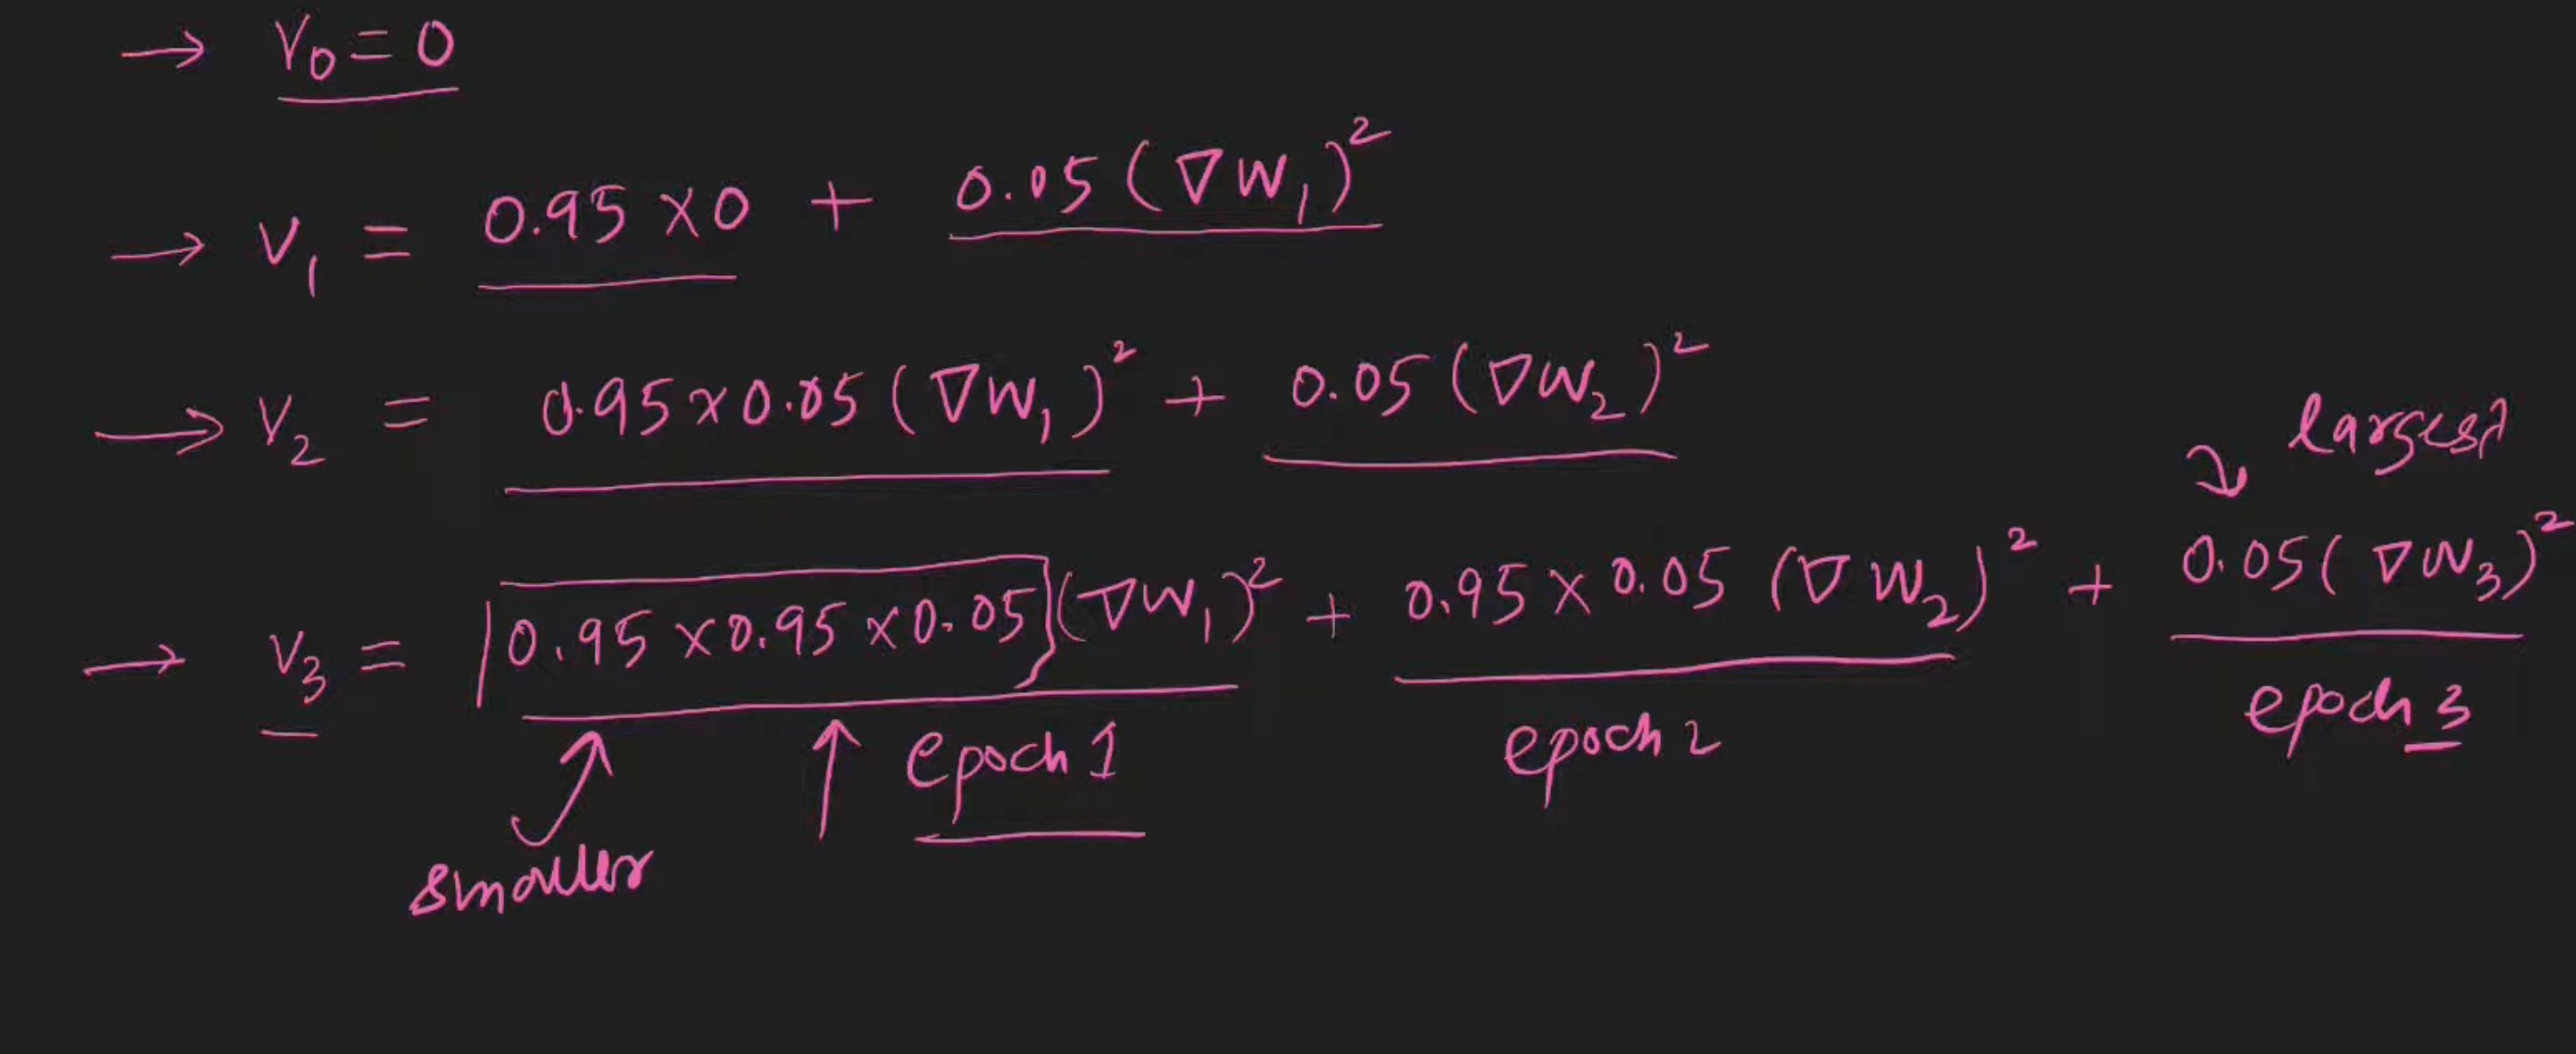

```
Step 1: V₁ = 0.95 × 0 + 0.05 × (g₁)² = 0.05 × (g₁)²
Step 2: V₂ = 0.95 × V₁ + 0.05 × (g₂)²
Step 3: V₃ = 0.95 × V₂ + 0.05 × (g₃)²
```

**Expanding Step 3 to see the weights:**
```
V₃ = 0.95² × 0.05 × (g₁)² + 0.95¹ × 0.05 × (g₂)² + 0.05 × (g₃)²
```

**Observe the pattern:**
- g₁ (oldest) gets multiplied by 0.9025 × 0.05 = very small number
- g₂ gets multiplied by 0.95 × 0.05 = smaller number
- g₃ (newest) gets multiplied by 0.05 = largest weight

**Key insight:** The weights decay exponentially as we go backward in time. Old gradients become practically zero after many steps.

**Why this solves AdaGrad's problem:**

| Algorithm | Vₜ calculation | Does Vₜ grow forever? |
|-----------|----------------|----------------------|
| AdaGrad | Sum of ALL past (gradient)² | ✓ YES → learning rate → 0 |
| RMSProp | β × Vₜ₋₁ + (1-β) × (gradient)² | ✗ NO → stabilizes |

---

### 3. Key Points

- **Vₜ** = exponentially weighted moving average of squared gradients
- **β (beta)** = decay rate (typically 0.9 or 0.95) - controls forgetting speed
- **1-β** = weight given to current gradient
- Older gradients get **exponentially smaller** weights
- Vₜ never explodes like AdaGrad's sum does
- The denominator √(Vₜ) in parameter update stays reasonable

**Weight distribution with β = 0.9:**
- Current gradient: 10% weight
- Previous gradient: 9% weight (0.9 × 0.1)
- 2 steps ago: 8.1% weight
- 3 steps ago: 7.29% weight

---

### 8. Interview/Exam Questions

**Q1: What does the β (beta) parameter control in RMSProp?**
> **A:** β controls the decay rate - how much weight is given to past squared gradients versus the current one. Higher β (closer to 1) means more smoothing and longer memory; lower β means more responsive to recent changes. Typical values are 0.9 or 0.95.

**Q2: Write the update rule for Vₜ in RMSProp.**
> **A:** Vₜ = β × Vₜ₋₁ + (1 - β) × (gradient)²

**Q3: Why doesn't Vₜ grow infinitely large in RMSProp like it does in AdaGrad?**
> **A:** Because RMSProp uses exponential decay - each step multiplies the previous Vₜ by β (< 1), and old gradients get exponentially smaller weights. AdaGrad simply adds without any decay, causing unbounded growth.

**Q4: If β = 0.9, roughly how much weight does a gradient from 10 steps ago have?**
> **A:** Approximately 0.9¹⁰ ≈ 0.35 of its original contribution, and it gets multiplied further by (1-β) = 0.1, making it very small overall.

---

### 9. Revision Notes

- **Vₜ = β × Vₜ₋₁ + (1 - β) × gₜ²** ← Core RMSProp formula
- **β** = decay rate (≈ 0.9 to 0.95)
- **1-β** = weight for current gradient
- **Exponential decay** = older values get multiplied by β repeatedly → become negligible
- **Result** = Vₜ stabilizes, doesn't grow forever
- **Denominator √(Vₜ)** in parameter update prevents learning rate from becoming zero

**Simple memory trick:**
- AdaGrad = "I remember EVERYTHING" → memory overload → stops learning
- RMSProp = "I remember recent things clearly, old things fade" → healthy memory → keeps learning

---



## Topic 3: RMSProp vs AdaGrad – Animation & Performance Comparison

### 1. Introduction

**What are we comparing?**
AdaGrad and RMSProp are both optimization algorithms, but they behave very differently depending on the type of problem. Understanding when each one works best helps you choose the right tool.

**Why this matters for beginners:**
You won't always use RMSProp. Sometimes AdaGrad is fine. Sometimes neither works well. Knowing the difference saves you hours of debugging failed training.

**Real-life analogy:**
- **AdaGrad** = A car that drives perfectly on a straight highway but slows to a crawl on winding mountain roads
- **RMSProp** = An all-terrain vehicle that handles both highways AND mountain roads well

---

### 2. Detailed Explanation

**Two Types of Optimization Problems**

| Problem Type | Shape | Example | What happens |
|--------------|-------|---------|--------------|
| **Convex** | Bowl-shaped (one minimum) | Linear Regression | Easy to find minimum |
| **Non-convex** | Wavy, many hills & valleys | Complex Neural Networks | Many local minima, easy to get trapped |

**Animation Results (as described in the transcript):**

**Scenario 1: Linear Regression (Convex Problem)**

| Algorithm | Performance | What happens |
|-----------|-------------|--------------|
| AdaGrad | ✓ Converts to global minimum | Works perfectly |
| RMSProp | ✓ Converts to global minimum | Works perfectly |

*Result:* Both algorithms reach the minimum successfully.

**Scenario 2: Complex Neural Network (Non-convex Problem)**

| Algorithm | Performance | What happens |
|-----------|-------------|--------------|
| AdaGrad | ✗ Cannot reach minimum | Gets stuck before reaching the true minimum |
| RMSProp | ✓ Reaches minimum | Continues updating and successfully converges |

*Result:* RMSProp succeeds where AdaGrad fails.

---

**Visualizing the Difference (Mental Picture)**

Imagine a landscape with mountains and valleys. You're trying to reach the lowest valley.

**AdaGrad's trajectory:**
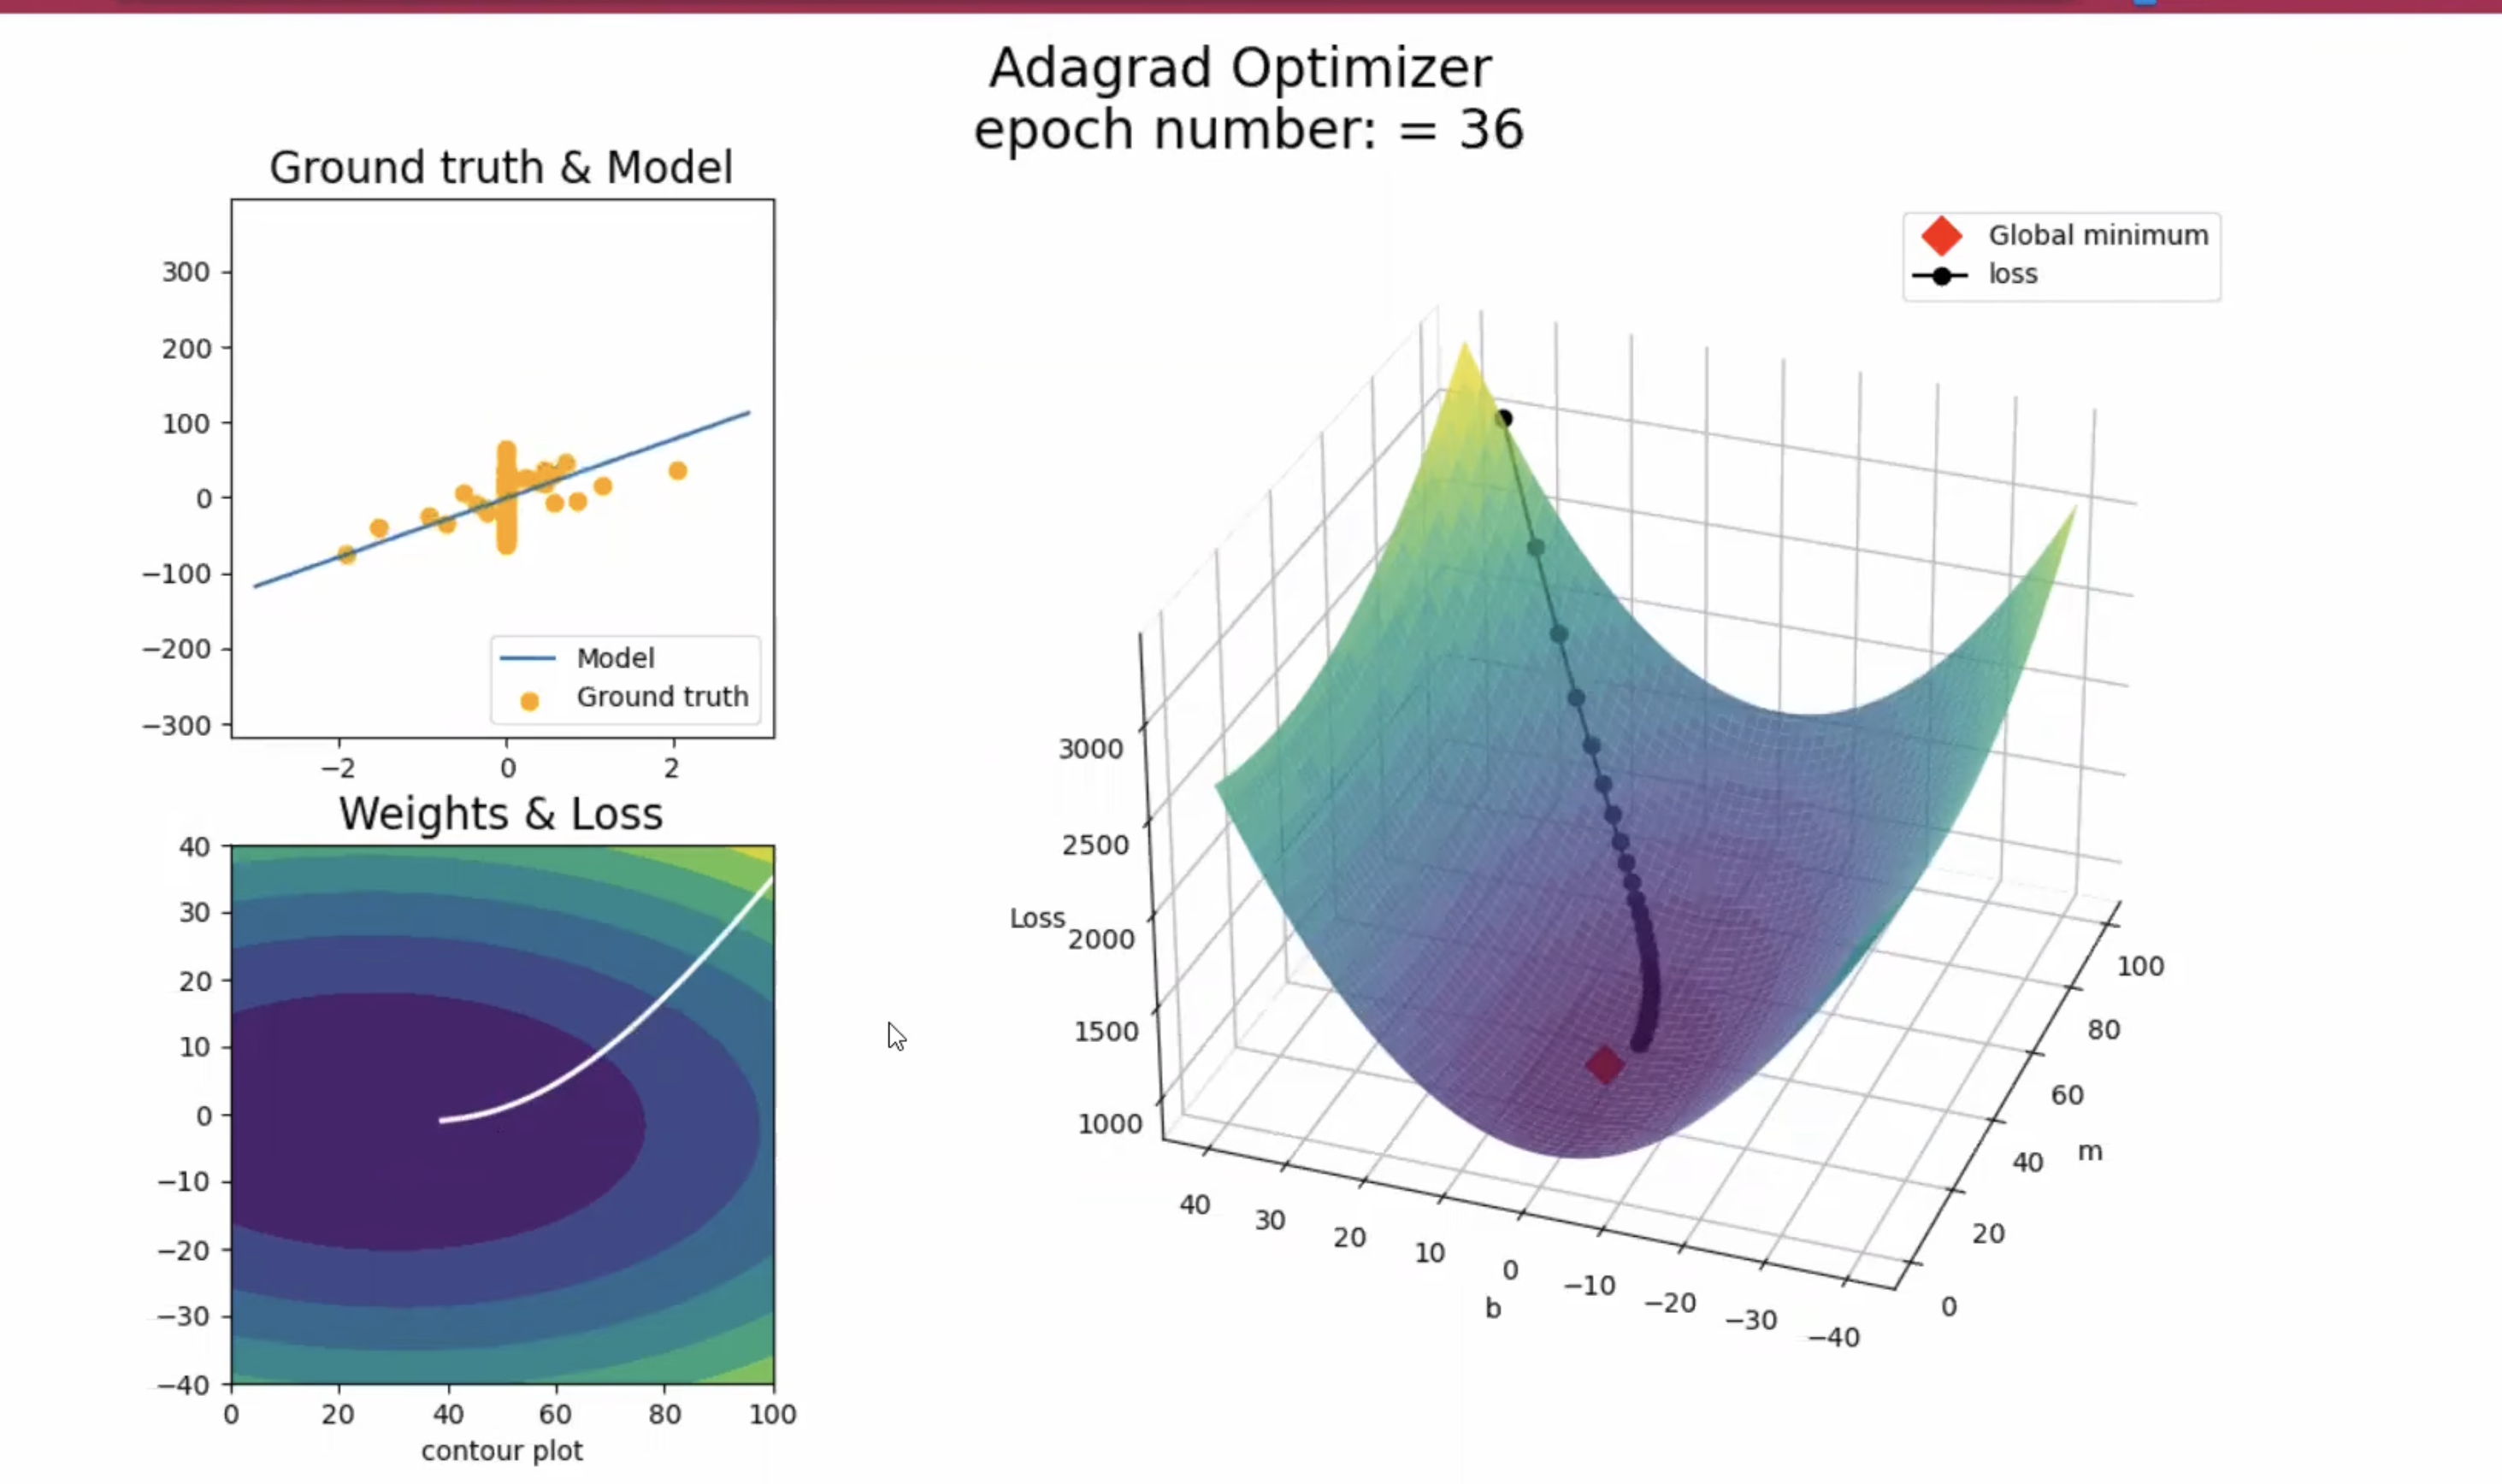
- Starts with normal steps
- Gradually slows down
- Gets stuck on a small hill before reaching the lowest point
- Stops moving entirely

**RMSProp's trajectory:**
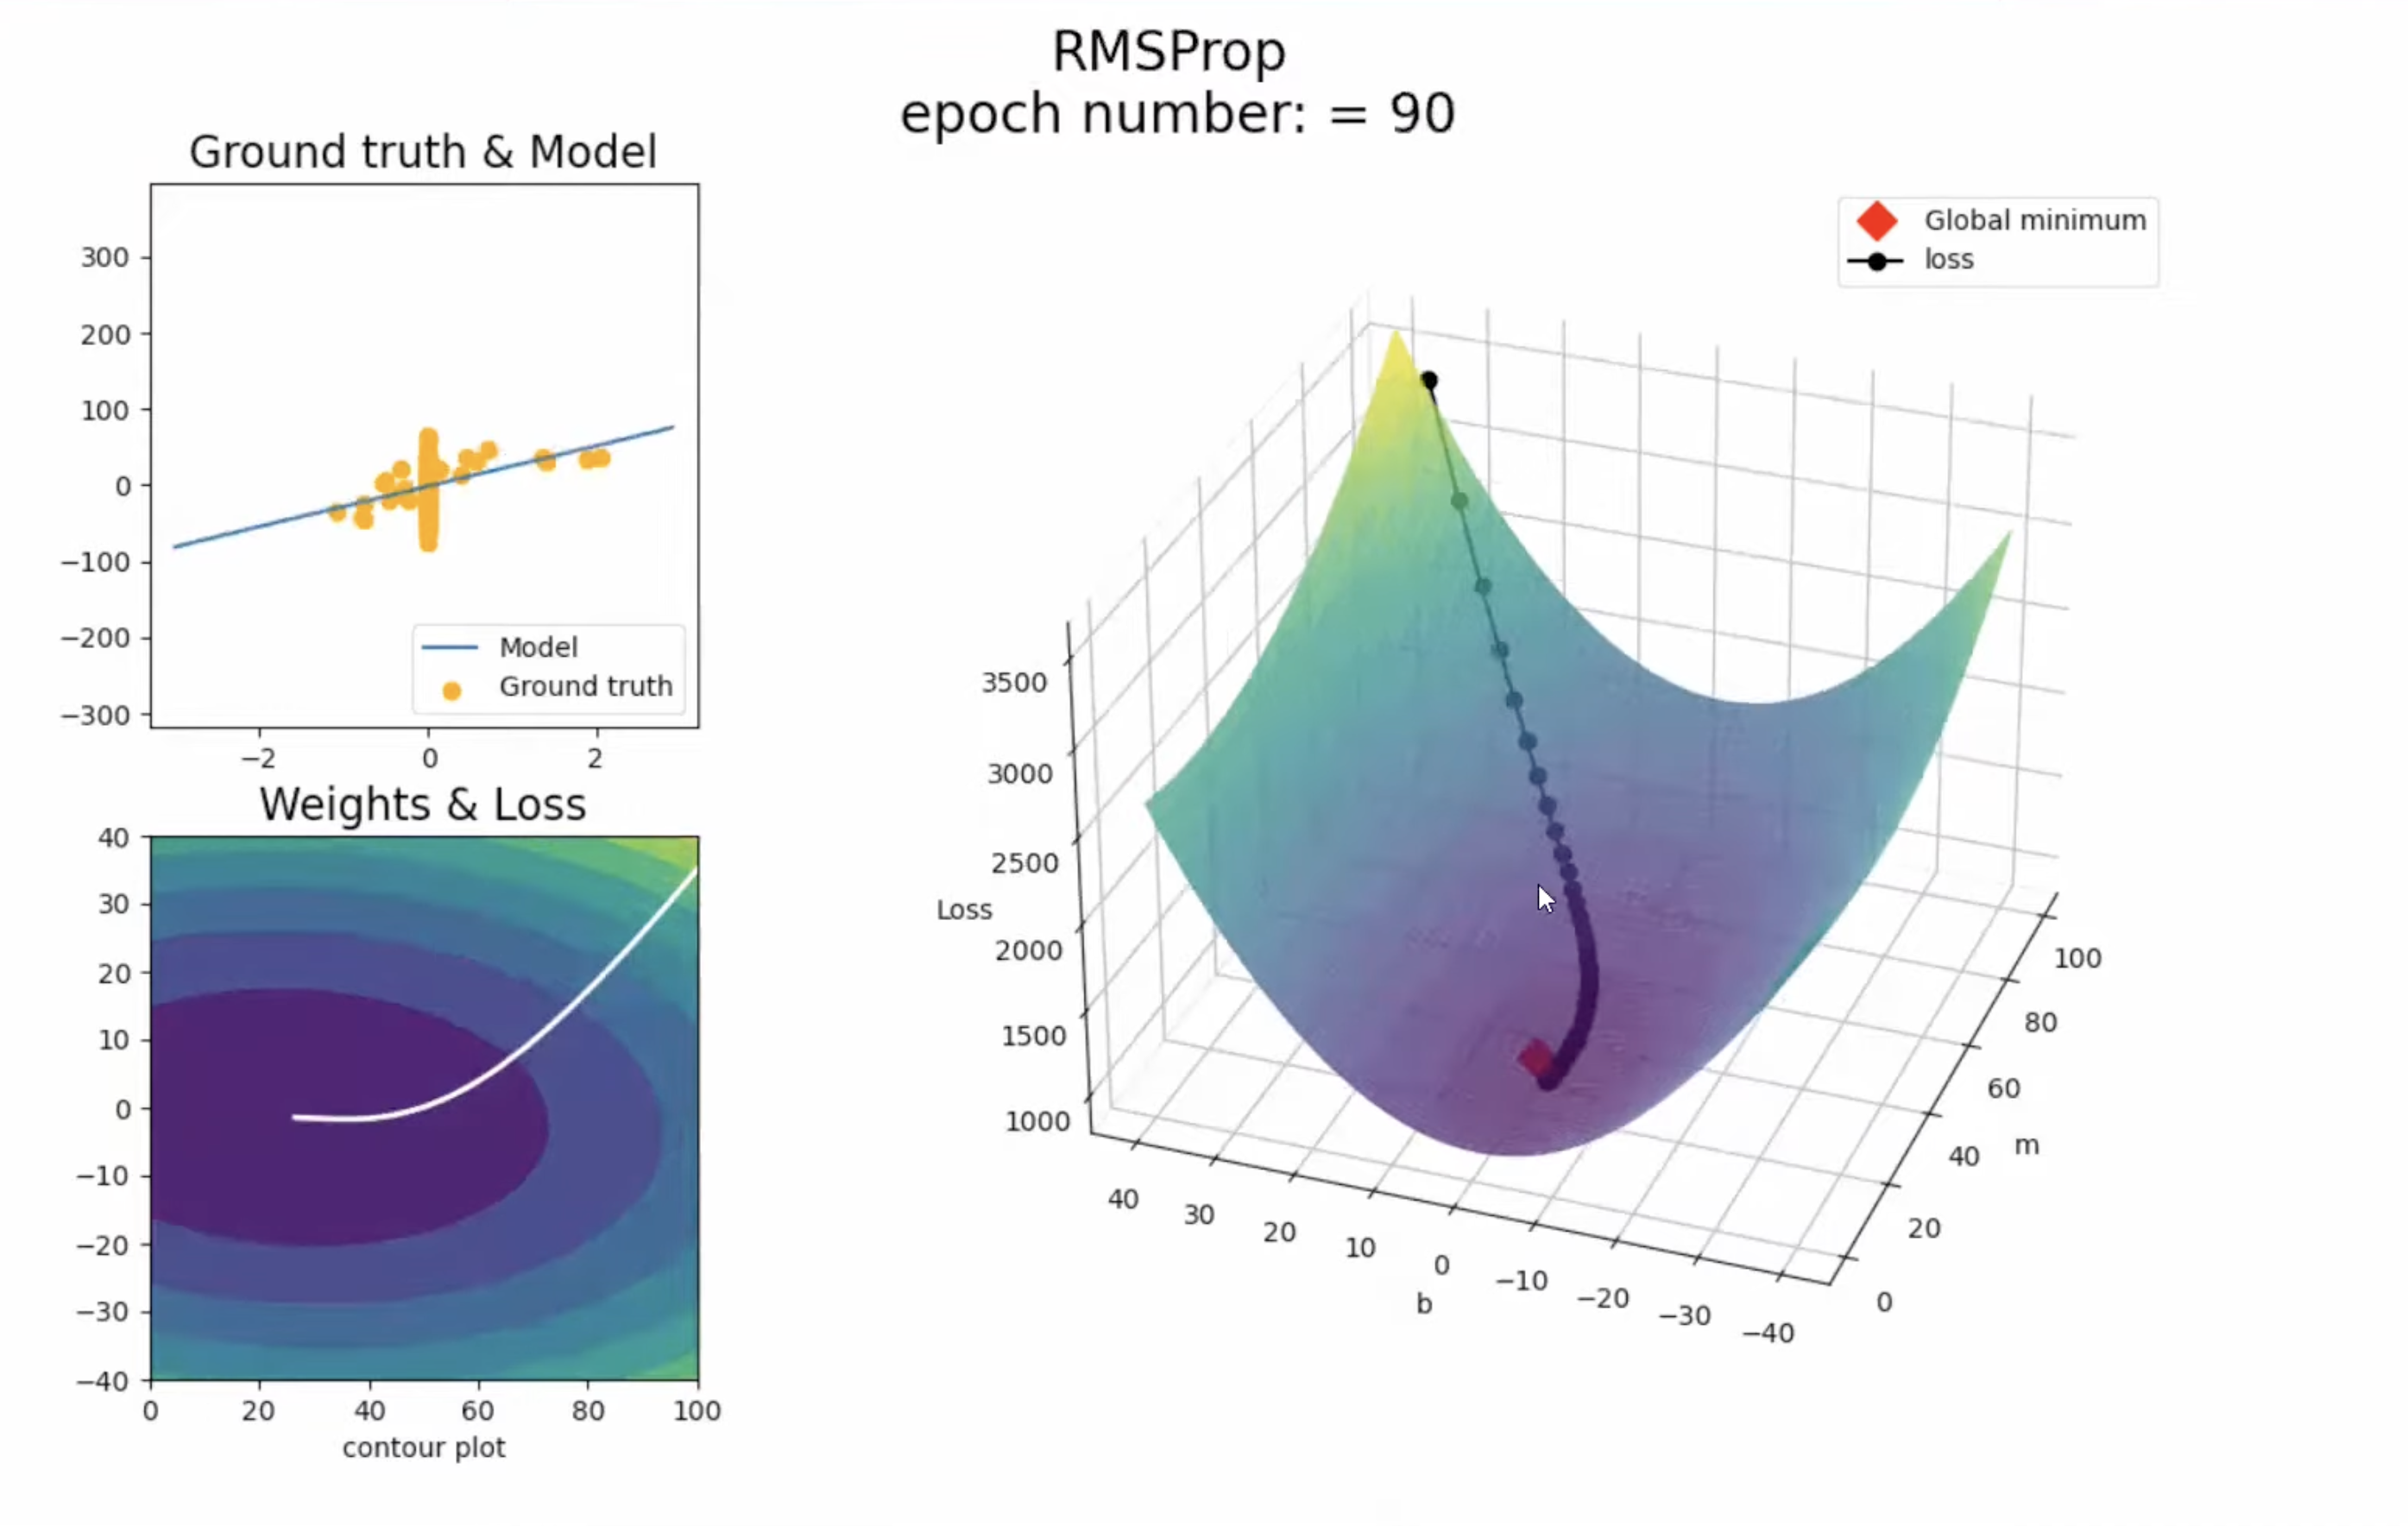
- Starts with normal steps
- Maintains reasonable step sizes
- Navigates past small hills
- Reaches the true minimum

**Why AdaGrad fails in non-convex problems:**
- Non-convex landscapes have many "bumps" and "local minima"
- AdaGrad's learning rate becomes tiny over time
- Once it enters a small dip (local minimum), it can't climb out
- The tiny learning rate means no movement → stuck forever

**Why RMSProp succeeds:**
- Maintains larger learning rate due to Vₜ not exploding
- Can "jump" out of small local minima
- Continues exploring the landscape
- Eventually finds the global minimum

---

### 3. Key Points

| Aspect | AdaGrad | RMSProp |
|--------|---------|---------|
| **Convex problems** (Linear Regression) | ✓ Works | ✓ Works |
| **Non-convex problems** (Neural Networks) | ✗ Gets stuck | ✓ Works |
| **Learning rate over time** | Continuously decreases → becomes tiny | Remains reasonable |
| **Ability to escape local minima** | No (stops moving) | Yes (keeps updating) |

**Summary bullet points:**
- Both algorithms work fine for simple, convex problems
- RMSProp is superior for complex, non-convex neural networks
- AdaGrad's fatal flaw: learning rate → 0 over time
- RMSProp's advantage: maintains healthy learning rate throughout training

---

### 7. Common Mistakes

| Mistake | Why it happens | How to avoid |
|---------|---------------|--------------|
| Using AdaGrad for deep neural networks | Not knowing the difference between convex and non-convex problems | Use RMSProp or Adam for neural networks; AdaGrad is better for simpler models like linear regression |
| Expecting identical performance on all problems | Every optimizer has strengths and weaknesses | Test different optimizers on YOUR specific problem |

---

### 8. Interview/Exam Questions

**Q1: For which type of optimization problem does AdaGrad fail, and why?**
> **A:** AdaGrad fails for non-convex optimization problems (like complex neural networks). It fails because its learning rate continuously decreases and becomes extremely small, causing the algorithm to get stuck in local minima before reaching the global minimum.

**Q2: Would you use AdaGrad or RMSProp for training a deep neural network on image recognition? Why?**
> **A:** RMSProp, because deep neural networks create non-convex optimization problems. RMSProp maintains a reasonable learning rate throughout training and can escape local minima, while AdaGrad would slow down too much and get stuck.

**Q3: If you have a simple linear regression problem, do you need RMSProp over AdaGrad?**
> **A:** No. Both work well for convex problems like linear regression. AdaGrad is sufficient. However, RMSProp would also work fine.

---

### 9. Revision Notes

**Convex problems (bowl-shaped):**
- AdaGrad = ✓ Works
- RMSProp = ✓ Works
- Example: Linear Regression

**Non-convex problems (wavy, complex):**
- AdaGrad = ✗ Gets stuck (learning rate too small)
- RMSProp = ✓ Reaches minimum (learning rate stays healthy)
- Example: Complex Neural Networks

**Key takeaway:**
> AdaGrad is like a car that stops on hills. RMSProp keeps climbing.

**Current status (from transcript):**
- RMSProp was one of the best optimizers for neural networks before Adam arrived
- RMSProp is still used today when Adam doesn't give good results
- It remains a "very, very powerful optimization technique"

---



## Topic 4: Practical Usage, Advantages & Current Status of RMSProp

### 1. Introduction

**Where does RMSProp stand today?**
RMSProp was once one of the most popular optimizers for training neural networks. Today, **Adam** (Adaptive Moment Estimation) is more commonly used, but RMSProp remains an important backup option.

**Why this matters:**
Knowing when to use RMSProp (instead of Adam or other optimizers) can save your neural network training when default choices fail.

**Real-life use cases:**
- Training complex neural networks where AdaGrad fails
- As a fallback when Adam doesn't produce good results
- Understanding RMSProp helps you understand Adam (Adam = RMSProp + Momentum)

---

### 2. Detailed Explanation

**The Evolution of Optimizers (Timeline)**

```
AdaGrad → RMSProp → Adam
(early)    (improvement)  (RMSProp + Momentum)
```

| Optimizer | Key Feature | Limitation |
|-----------|-------------|-------------|
| AdaGrad | Adaptive learning rates | Learning rate becomes too small |
| RMSProp | Fixes the learning rate problem | No momentum component |
| Adam | RMSProp + Momentum | More complex, more hyperparameters |

**What is Adam?**
- Adam = **RMSProp + Momentum**
- Takes the best of both: adaptive learning rates (from RMSProp) + momentum for smoother updates
- This is why Adam is often better than RMSProp alone

**When should you use RMSProp today?**

| Scenario | Recommendation |
|----------|---------------|
| Default choice for most neural networks | Try **Adam** first |
| Adam gives poor results on your problem | **Switch to RMSProp** |
| You understand RMSProp and want simpler optimizer | RMSProp is fine |
| Your problem is convex (e.g., linear regression) | AdaGrad or RMSProp both work |

**Quote from transcript:**
> "If you have any problem, Adam is so good. If you don't get results, then you can still apply RMSProp today."

**Advantages of RMSProp:**

1. ✓ Solves AdaGrad's diminishing learning rate problem
2. ✓ Works well for both convex and non-convex problems
3. ✓ Less aggressive decay than AdaGrad
4. ✓ Still one of the "best optimization techniques" for neural networks
5. ✓ Foundation for understanding Adam

**Disadvantages mentioned in transcript:**
- ✗ Slightly less used today (since Adam arrived)
- ✗ Adam generally performs better (but not always)

---

### 3. Key Points

**Quick Reference Table:**

| Aspect | Detail |
|--------|--------|
| Full form | Root Mean Square Propagation |
| Invented | As an improvement to AdaGrad |
| Best for | Non-convex neural network optimization |
| Current popularity | Less than Adam, but still used |
| When to use | When Adam doesn't work well |
| Relationship to Adam | Adam = RMSProp + Momentum |

**Summary:**
- RMSProp is not the most popular optimizer today (Adam is)
- But RMSProp is still **very, very powerful**
- It remains a valuable tool in your optimization toolkit
- Use it when Adam fails to give good results

---

### 7. Common Mistakes

| Mistake | Why it happens | How to avoid |
|---------|---------------|--------------|
| Never trying RMSProp because "Adam is always better" | Assuming newer always = better for YOUR problem | Always test multiple optimizers; Adam isn't universally superior |
| Using RMSProp without understanding β parameter | Copying code without learning | Learn what β does (typically 0.9 or 0.95) |
| Expecting RMSProp to work on every problem | No optimizer works for everything | Experiment with different optimizers |

---

### 8. Interview/Exam Questions

**Q1: What is the relationship between RMSProp and Adam?**
> **A:** Adam combines RMSProp with momentum. Adam = RMSProp (adaptive learning rates via squared gradients) + Momentum (smoothed gradients). This makes Adam generally more effective than RMSProp alone.

**Q2: Is RMSProp still used today? If so, when?**
> **A:** Yes, RMSProp is still used today. It is typically used as a fallback when Adam doesn't produce good results on a specific problem. It remains a very powerful optimization technique.

**Q3: What came first: RMSProp or Adam?**
> **A:** RMSProp came first, then Adam. RMSProp was developed to improve AdaGrad. Later, Adam was developed by combining RMSProp with momentum.

**Q4: Should you always use Adam instead of RMSProp?**
> **A:** No. While Adam is generally better for most problems, RMSProp can sometimes produce better results. You should try both optimizers for your specific problem and compare performance.

---

### 9. Revision Notes

**Optimizer Evolution Chain:**
```
AdaGrad → RMSProp → Adam
   ↓         ↓         ↓
gets stuck  fixed      RMSProp
            learning   + 
            rate       Momentum
```

**When to use RMSProp:**
- ✓ Adam gives poor results on your problem
- ✓ You want a simpler alternative to Adam
- ✓ You're training non-convex neural networks

**When to use Adam first:**
- ✓ Most deep learning tasks
- ✓ When you don't have a specific reason to choose RMSProp

**Key takeaway:**
> RMSProp is not dead. It's a powerful fallback when Adam fails. Understanding RMSProp is also essential for understanding Adam.

**Final quote from transcript:**
> "RMSProp is one of the best optimization techniques to optimize neural networks... It's still a very, very powerful optimization technique."

---

**You have now completed all topics from the transcript:**

1. ✓ Introduction to RMSProp & The Problem It Solves
2. ✓ Mathematical Formula & Exponentially Weighted Average
3. ✓ RMSProp vs AdaGrad – Animation & Performance Comparison
4. ✓ Practical Usage, Advantages & Current Status of RMSProp

